In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

## Inspect `testfdd.cpp`'s mock burst

Input dimensions (channels, time slots): (119999, 16)
Output dimensions (time slots, DMs): (119960, 11)
Number of trial DMs: 11


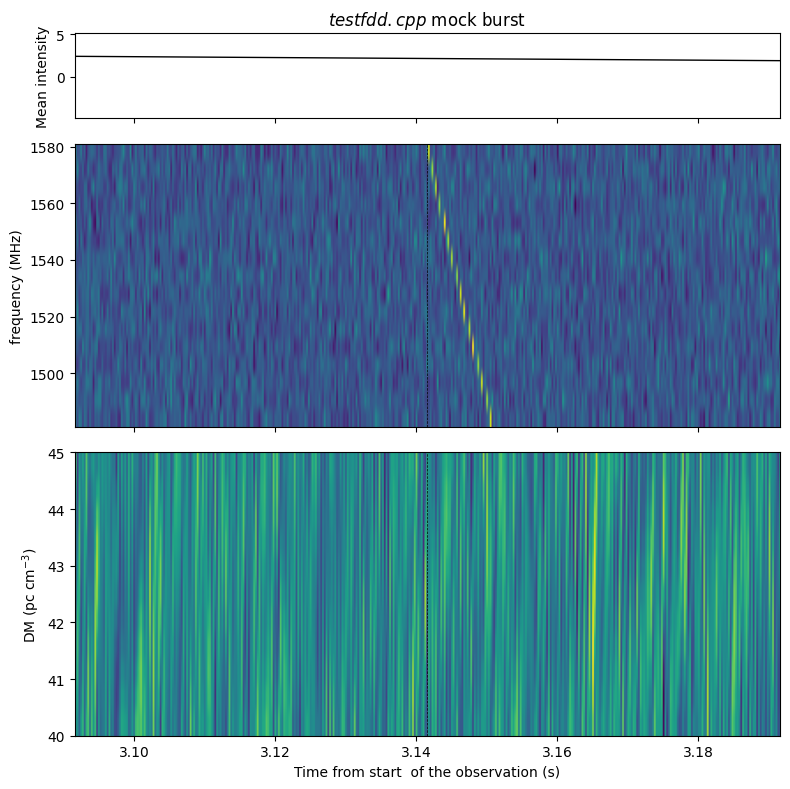

In [2]:
# Select data directory
data_dir = Path().cwd()
assert data_dir.exists()

# Load the data: input, output, and trial DMs
fdd_input = np.load(data_dir / 'fddin_float.npy')
print(f'Input dimensions (channels, time slots): {fdd_input.shape}')

fdd_output = np.load(data_dir / 'fddout.npy')
print(f'Output dimensions (time slots, DMs): {fdd_output.shape}')

dm_table = np.load(data_dir / 'dmtable.npy')
print(f'Number of trial DMs: {dm_table.size}')

# Settings
t_burst = np.pi
t_samp = 250.0e-6
n_samp = fdd_input.shape[0]

t_start = 0
t_end = t_samp * n_samp

f_max = 1581.0 # MHz
bandwidth = 100
n_chans = fdd_input.shape[1]
chan_width = bandwidth / n_chans 

f_min = f_max - chan_width * n_chans

dt = 0.05
select_start = t_burst - dt
select_end = t_burst + dt

samp_start = int(select_start / t_samp)
samp_end = int(select_end / t_samp)    

# Plot the burst and the trial DMs
fig, frames = plt.subplots(3, 1, sharex=True, figsize=(8, 8), gridspec_kw=dict(height_ratios=[0.3, 1,1]))

# Plot the channel-averaged burst
mean_intensity = np.mean(fdd_input[samp_start:samp_end,:], axis=1)
frames[0].plot(mean_intensity, lw=1, color='black')

# Plot the input data (samples, channel)
spec = frames[1].imshow(fdd_input[samp_start:samp_end,:].T, aspect='auto', extent=(select_start, select_end, f_min, f_max))
# plt.colorbar(spec)

# Plot the output trial DM space (samples, trial DMs)
dm_space = frames[2].imshow(fdd_output[samp_start:samp_end,:].T, origin='lower', aspect='auto', extent=(select_start, select_end, dm_table.min(), dm_table.max())) # TODO: check whether we actually need to set the 'origin'...
# plt.colorbar(dm_space)

# Axes settings
frames[0].set_title(r'$\it{testfdd.cpp}$ mock burst')
frames[0].set_ylabel('Mean intensity')
frames[0].set_ylim(mean_intensity.mean() - 5, mean_intensity.mean() + 5)

frames[1].axvline(t_burst, color='black', ls='--', lw=0.5)
frames[1].set_ylabel('frequency (MHz)')

frames[2].axvline(t_burst, color='black', ls='--', lw=0.5)
frames[2].set_xlabel('Time from start  of the observation (s)')
frames[2].set_ylabel(r'DM (pc cm$^{-3}$)')

plt.tight_layout()

# fig.savefig('testfdd-burst-plot.png')
plt.show()

## Inspect `testfil.cpp`'s real burst

Input dimensions (channels, time slots): (4489216, 1024)
Output dimensions (time slots, DMs): (4468690, 38)
Number of trial DMs: 38


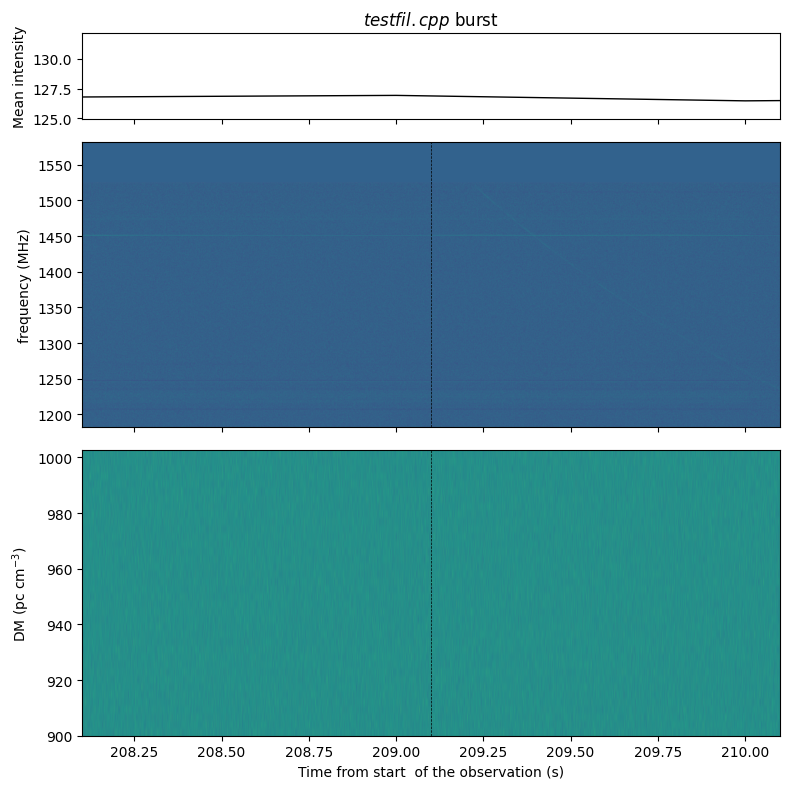

In [64]:
# Select data directory
fil_dir = Path().home() / 'scratch' / 'workspace' / 'dedisp-with-filterbanks'
assert fil_dir.exists()


# Load the data: input, output, and trial DMs
fdd_input = np.load(fil_dir / 'fddin_fil.npy')
print(f'Input dimensions (channels, time slots): {fdd_input.shape}')

fdd_output = np.load(fil_dir / 'fddout_fil.npy')
print(f'Output dimensions (time slots, DMs): {fdd_output.shape}')

dm_table = np.load(fil_dir / 'dmtable_fil.npy')
print(f'Number of trial DMs: {dm_table.size}')

# Settings
t_burst = 209.1
t_samp = 6.4e-5
n_samp = fdd_input.shape[0]

t_start = 0
t_end = t_samp * n_samp

f_max = 1581.8 # MHz
chan_width = 0.390625
n_chans = fdd_input.shape[1]

f_min = f_max - chan_width * n_chans

dt = 1
select_start = t_burst - dt
select_end = t_burst + dt

samp_start = int(select_start / t_samp)
samp_end = int(select_end / t_samp)    

# Plot the burst and the trial DMs
fig, frames = plt.subplots(3, 1, sharex=True, figsize=(8, 8), gridspec_kw=dict(height_ratios=[0.3, 1,1]))

# Plot the channel-averaged burst
mean_intensity = np.mean(fdd_input[samp_start:samp_end,:], axis=1)
frames[0].plot(mean_intensity, lw=1, color='black')

# Plot the input data (samples, channel)
spec = frames[1].imshow(fdd_input[samp_start:samp_end,:].T, aspect='auto', extent=(select_start, select_end, f_min, f_max))
# plt.colorbar(spec)

# Plot the output trial DM space (samples, trial DMs)
dm_space = frames[2].imshow(fdd_output[samp_start:samp_end,:].T, origin='lower', aspect='auto', extent=(select_start, select_end, dm_table.min(), dm_table.max())) # TODO: check whether we actually need to set the 'origin'...
# plt.colorbar(dm_space)

# Axes settings
frames[0].set_title(r'$\it{testfil.cpp}$ burst')
frames[0].set_ylabel('Mean intensity')

frames[1].axvline(t_burst, color='black', ls='--', lw=0.5)
frames[1].set_ylabel('frequency (MHz)')

frames[2].axvline(t_burst, color='black', ls='--', lw=0.5)
frames[2].set_xlabel('Time from start  of the observation (s)')
frames[2].set_ylabel(r'DM (pc cm$^{-3}$)')

plt.tight_layout()

# fig.savefig('testfil-burst-plot.png')
plt.show()

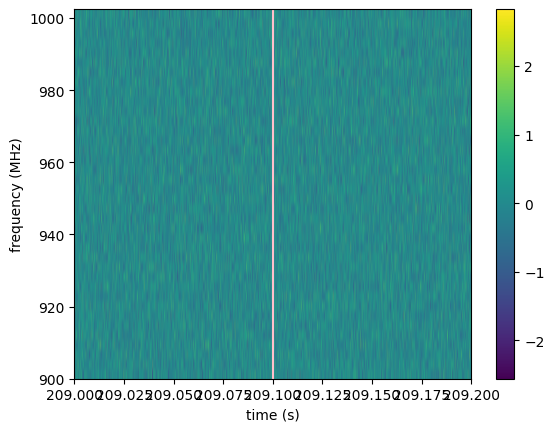

In [24]:
dt = 0.1
select_start = t_burst - dt
select_end = t_burst + dt

samp_start = int(select_start / t_samp)
samp_end = int(select_end / t_samp)    

plt.imshow(fdd_output[samp_start:samp_end,:].T, origin='lower', aspect='auto', extent=(select_start, select_end, dm_table.min(), dm_table.max()))
plt.colorbar()
plt.axvline(t_burst, color='pink')
plt.xlabel('time (s)')
plt.ylabel('frequency (MHz)')
plt.show()